In [73]:
import seaborn as sns   
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import joblib

In [74]:
df = pd.read_parquet('../data_sample/datos_licitaciones.parquet', engine='fastparquet')


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37700 entries, 572837 to 2087811
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Situació contractual                 37700 non-null  object 
 1   Exercici                             37700 non-null  int64  
 2   Àmbit organitzatiu                   37700 non-null  object 
 3   Identificador agrupació organisme    37700 non-null  object 
 4   Agrupació organisme                  37700 non-null  object 
 5   Identificador organisme contractant  37700 non-null  object 
 6   Organisme contractant                37700 non-null  object 
 7   Codi de l’expedient                  37700 non-null  object 
 8   Procediment d’adjudicació            37700 non-null  object 
 9   Tipus de contracte                   37700 non-null  object 
 10  Descripció de l’expedient            37700 non-null  object 
 11  Número de lot             

In [76]:
df

,Situació contractual,Exercici,Àmbit organitzatiu,Identificador agrupació organisme,Agrupació organisme,Identificador organisme contractant,Organisme contractant,Codi de l’expedient,Procediment d’adjudicació,Tipus de contracte,...,Tipus de modificació,Import de la modificació,Data aprovació modificació,Termini modificació anys,Termini modificació mesos,Termini modificació dies,Tipus de liquidació,Data de liquidació,Causa de resolució,Import de la liquidació
572837,liquidació,2022,Entitats de l'Administració Local,4316280001,Ajuntament de Vandellòs i l'Hospitalet de l'In...,4316280001,Ajuntament de Vandellòs i l'Hospitalet de l'In...,0225 / 2022,Menor,3. SUBMINISTRAMENTS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,08/02/2022,,2.38
609033,liquidació,2023,Departaments i Sector Públic de la Generalitat...,1500,DEPARTAMENT DE SALUT,1542,Institut Català de la Salut (ICS) Barcelonès H...,1101369832,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,14/11/2023,,170.68
1612984,liquidació,2024,Entitats de l'Administració Local,0822050006,Ajuntament de Sant Julià de Vilatorta,0822050006,Ajuntament de Sant Julià de Vilatorta,SU41,Menor,3. SUBMINISTRAMENTS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,13/05/2024,,45.81
1412433,liquidació,2021,Departaments i Sector Públic de la Generalitat...,1400,DEPARTAMENT DE CULTURA,7915100002,Biblioteca de Catalunya,BC-2021-135,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,15/06/2021,,2150.13
951405,liquidació,2025,Entitats de l'Administració Local,8000840003,Diputació de Barcelona,8000840003,Diputació de Barcelona,2025/4118 - 9,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,25/03/2025,,880.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3383863,liquidació,2023,Departaments i Sector Públic de la Generalitat...,1500,DEPARTAMENT DE SALUT,7996100024,Fundació IDIAP Jordi Gol i Gurina,2023/R_107,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,24/02/2023,,926.73
3122031,liquidació,2023,Entitats de l'Administració Local,1711430008,Ajuntament d'Olot,1711430008,Ajuntament d'Olot,CC012023000848,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,13/12/2023,,2500.00
688482,liquidació,2021,Departaments i Sector Públic de la Generalitat...,9610930008,"DEPARTAMENT DE TERRITORI, HABITATGE I TRANSICI...",9805180001,Institut Metròpoli,F / 2021 / 339,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,15/12/2021,,220.00
3290182,liquidació,2025,Departaments i Sector Públic de la Generalitat...,9610930008,"DEPARTAMENT DE TERRITORI, HABITATGE I TRANSICI...",9610930818,Ferrocarrils de la Generalitat de Catalunya,CONTM/2025/0000001230,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,03/08/2025,,6321.47


In [77]:
df = df.loc[df["Import de la liquidació"] > 0].copy()


In [78]:
df["Import de la liquidació"].describe()

count    3.765300e+04
mean     2.874901e+03
std      2.990951e+04
min      1.000000e-02
25%      1.472000e+02
50%      4.800000e+02
75%      1.625000e+03
max      4.013769e+06
Name: Import de la liquidació, dtype: float64

In [24]:
'''
Podemos observar que todas las filas con el mismo tipo de situación, no nos aporta ningún tipo de información, por tanto, decidimos eliminarla

'''
df.iloc[:, 0].value_counts()
df.drop("Situació contractual", axis = 1, inplace = True)

In [25]:
'''
Si bien se trata ya de una feature numerica, para mejorar el rendimiento del modelo, aplicaremos una transformación, para que el modelo no interprete siempre estos valores
como año, dado que el modelo no entiende lo que son, solo que son modelos 

'''
df.iloc[:, 0].value_counts().sort_values()

clave_Exercici = {año: i for i, año in enumerate(range(2007, 2031))}

df["Exercici"] = df["Exercici"].map(clave_Exercici)

In [26]:
clave_Ambit_organitzatiu = {
    "Universitats": 0,
    "Departaments i Sector Públic de la Generalitat de Catalunya": 1,
    "Entitats de l'Administració Local": 2
}

df["Àmbit organitzatiu"] = df["Àmbit organitzatiu"].map(clave_Ambit_organitzatiu)

In [27]:
'''
Hemos descubierto que el campo "Identificador agrupació organisme" no se trata de un numero aleatorio, en realidad, tiene su propia nomenclatura, los primeros dos digitos
hacen referencia a la dirección postal del lugar de la licitación, por lo que podemos añadir una columna adicional a partir de esta, mas explicativa que el organismo contratante,
para identificar el lugar de la licitacion. En concreto, los codigos 08,17,25,43 hacen referencia a las direcciones postales de Barcelona, Girona, LLeida y Tarragona.
El resto de valores que no entran en estas caracteristicas, se tratan de organizaciones que no comprende este indice, y se hara una transformacion a parte
'''
df["Indice_Identificador_agrupació _organisme"] = df["Identificador agrupació organisme"].str[:2]
df["Indice_Identificador_agrupació _organisme"].value_counts()

clave_referencia_licitacio = {
    "08": "Barcelona",
    "80": "Barcelona",
    "96": "Departamentos_Estudio",
    "15": "Salud",
    "43": "Tarragona",
    "17": "Girona",
    "14": "Cultura",
    "25": "Lleida",
    "00": "Sociales",
    "81": "Consejo_Comarcal",
    "79": "Fundacion_privada",
    "98": "Desarrollo",
    "99": "Varios",
    "70": "Varios",
    "10": "Varios",
    "90": "Varios",
    "82": "Varios",
    "95": "Varios"

}

df["Referencia_Licitació"] = df["Indice_Identificador_agrupació _organisme"].map(clave_referencia_licitacio)
df["Referencia_Licitació"] = np.where(
    df["Identificador agrupació organisme"] =="8000",
    "Universidades",
    df["Referencia_Licitació"]
)

'''
Y ahora hacemos la transformación pertinente, para convertir la feature en numerica 
'''

clave_referencia_licitacio_numerico = {
    "Barcelona": 0,
    "Departamentos_Estudio": 1,
    "Salud": 2,
    "Tarragona": 3,
    "Universidades": 4,
    "Girona": 5,
    "Cultura": 6,
    "Lleida": 7,
    "Sociales": 8,
    "Consejo_Comarcal": 9,
    "Fundacion_privada": 10,
    "Desarrollo": 11,
    "Varios": 12,  
}
df["Referencia_Licitació"] = df["Referencia_Licitació"].map(clave_referencia_licitacio_numerico)

'''
Una vez resuelto esto, toca eliminar la columna del identificador, dada su alta cardinalidad
'''
df.drop("Identificador agrupació organisme", axis = 1, inplace = True)
df.drop("Indice_Identificador_agrupació _organisme", axis = 1, inplace = True)

In [28]:
'''
Tambien eliminaremos la columna agrupació organisme, identificador organisme, i organisme contractant, dada la transformación anterior que nos permite generalizar 
mucho mejor estos datos
'''
df.drop("Agrupació organisme", axis = 1, inplace = True)
df.drop("Identificador organisme contractant", axis = 1, inplace = True)
df.drop("Organisme contractant", axis = 1, inplace = True)

In [29]:
"""
Hemos intentado buscar documentacion acerca de la variable "Codi de l"expedient". Si bien da información, el problema es que se trata de una feature de texto libre, y esulta complicado
encontrar un patron para poder deducir la información, y poder hacer algo con ella. Afortunadamente, otras columnas del dataset ya son explicativas de las caracteristicas de 
dicho codigo, y por tanto, nos podemos permitir perder dicha columna
"""

df.drop("Codi de l’expedient", axis = 1, inplace = True)


In [30]:
'''
Vemos que tiene una estructura muy irregular, podemos transformar todos los valores menores en 0, y el resto ponerlo ponerlos en 1 
'''
df.iloc[:, 2].value_counts().sort_values()

df["Procediment d’adjudicació"] = np.where(
    df["Procediment d’adjudicació"] =="Menor",
    0,
    1
)


In [31]:
'''
Nuevamente una columna categorica, que podemos aplicar un mapeado para facilitar el proceso del modelo 
'''

clave_tipus_contracte = {
    "5. SERVEIS": 0,
    "3. SUBMINISTRAMENTS": 1,
    "1. OBRES": 2,
    "GESTIÓ DE SERVEI PÚBLIC": 3,
    "SERVEIS": 4,
    "10. PRIVAT D'ADMINISTRACIO PUBLICA": 5,
    "SUBMINISTRAMENTS": 6,
    "8. CONCESSIÓ DE SERVEIS": 7,
    "2. GESTIÓ DE SERVEI PÚBLIC": 8,
    "6. ADMINISTRATIU ESPECIAL": 9,
    "ADMINISTRATIU ESPECIAL": 10,
    "OBRES": 11,
    "COL·LABORACIÓ PÚBLIC- PRIVAT": 12,
    "CONCESSIÓ D'OBRA PÚBLICA": 13,
    "9. CONCESSIÓ D'OBRES": 14,
    "CONSULTORIA I ASSISTÈNCIA (antic)": 15
}

df["Tipus de contracte"] = df["Tipus de contracte"].map(clave_tipus_contracte)

In [32]:


df.iloc[:, 4].value_counts().sort_values(ascending= False)


Descripció de l’expedient
COMPRA DE FARMACIA                                           1206
Espectacle - PROGRAMA.CAT                                     280
Materials de Laboratori Científic (Varis:Óptica/Fotònica)     233
COMPRES/SERVEIS MENORS                                         87
REACTIUS                                                       84
                                                             ... 
Male BALB/cByJ MOUSE-AGE Range Cohort-Dr. Melgar                1
Pressupost n.3954 Cladellas. Subministrament joguines.          1
Ajustar porta corredissa entrada sud                            1
Mini ordenador Barebone Intel Nuc I3 8GB Ram 480GB              1
CRISTAL DCHO MTO                                                1
Name: count, Length: 31668, dtype: int64

In [33]:
'''
Esta columna esta perfecta tal y como viene, y no es neceario aplicar transformaciones.
'''

df.iloc[:, 5].value_counts().sort_values(ascending= False)


Número de lot
1     37551
2        37
3        15
4        12
5         6
8         4
7         4
6         3
15        2
16        2
9         2
10        2
17        1
35        1
27        1
13        1
53        1
11        1
18        1
32        1
24        1
59        1
25        1
47        1
37        1
Name: count, dtype: int64

In [34]:
'''
El codigo cpv contiene información muy interesante acerca del ambito al que se pueda referir la licitacion, para ello necesitamos hacer una transformacion de la columna, y 
procesar los datos
'''
df.iloc[:, 6].value_counts().sort_values(ascending= False)
df["Codi_CPV_def"] = df["Codi CPV"].str[:8]

with open('../data_sample/Codigos_CPV.txt', 'r', encoding= "utf-8") as f:
    lineas = f.readlines()

datos = [linea.strip().split('-', 1) for linea in lineas]

df_CPV = pd.DataFrame(datos, columns=['Codi_CPV', 'Descripcio_CPV'])

In [35]:
df_CPV

,Codi_CPV,Descripcio_CPV
0,03000000,"Productos de la agricultura, ganadería, pesca..."
1,03100000,Productos de la agricultura y horticultura
2,03110000,"Cultivos, productos comerciales de jardinería..."
3,03111000,Semillas
4,03111100,Soja
...,...,...
9449,98513300,Personal temporal para particulares
9450,98513310,Servicios de ayuda en tareas domésticas
9451,98514000,Servicios domésticos
9452,98900000,Servicios prestados por organizaciones y enti...


In [36]:
df['Codi_CPV_def'] = df['Codi_CPV_def'].astype(str).str.strip()
df_CPV['Codi_CPV'] = df_CPV['Codi_CPV'].astype(str).str.strip()

In [37]:
df = df.merge(df_CPV[['Codi_CPV', 'Descripcio_CPV']], left_on='Codi_CPV_def', right_on='Codi_CPV', how='left')


In [38]:
'''
Una vez hecho el procesado de esta columna, podemos eliminar las columnas de información relativa para evitar
ruido en el modelo. Por desgracia, esta columna no estaba complimentada originalmente, por lo que debemos
generalizar en los nulos, poniendo "Desconocido", en cada uno de ellos
'''

df.drop(columns=['Codi CPV', 'Codi_CPV_def', 'Codi_CPV'], inplace=True)
df["Descripcio_CPV"] = df["Descripcio_CPV"].fillna("Desconocido")


In [39]:
'''
Ahora queda transformar la feature en numerico para que facilite el procesado el modelo, ademas viendo el value couunts, podemos observar que la variable sera sensible 
a la escala, asi que es mejor hacer el procesado de esta forma. Para transformarla, haremos uso de una funcion de frecuencia
'''

freq = df["Descripcio_CPV"].value_counts(normalize=True)
df["Descripcio_CPV"] = df['Descripcio_CPV'].map(freq)

In [40]:
'''
La siguiente columna es una interesante, si bien en un principio aparenta ser una columna de texto libre, y podriamos hacer uso de una funcion de frecuencia, es interesante
que los nombres de las empresas aparezcan multiples veces, escritos de forma diferente. La funcion de frecuencia no es la ideal, pero otras optativas como el tfidf nos genera 
una dimensionalidad enorme, por lo que usaremos la funcion de frecuencia, pese a no ser la ideal

'''
freq = df["Adjudicatari"].value_counts(normalize=True)
df["Adjudicatari"] = df['Adjudicatari'].map(freq)


In [41]:
'''
No transformaremos ni modificaremos la columna de "Import d'adjudicacio" dado que esta en un formato muy conveniente,
y seguro sera la que dara la mayor explicabilidad de la target. Luego debemos ver si realmente se 
trata de los mismos valores liquidacion de adjudicacion mediante una matriz de correlacion 
'''

'\nNo transformaremos ni modificaremos la columna de "Import d\'adjudicacio" dado que esta en un formato muy conveniente,\ny seguro sera la que dara la mayor explicabilidad de la target. Luego debemos ver si realmente se \ntrata de los mismos valores liquidacion de adjudicacion mediante una matriz de correlacion \n'

In [42]:
'''
Para la transformacion de la siguiente columnas, que se trata de fechas, en formato de europa, decidimos transformar los numeros en unix timestamp,
y luego, crear columnas adicionales para representar el dia, mes y año, que tratan, asi al modelo no le afectara la escala de los datos, y no le 
dejaremos la libre interpretacion de la distancia entre fechas(por ejemplo del 28/02/2026 a 01/03/2026, se trata de una diferencia minuscula,
pero estos valores no los interpreta )
'''
df["Data d’adjudicació"] = pd.to_datetime(df["Data d’adjudicació"], format='%d/%m/%Y')
df["fecha_unix_adj"] = df["Data d’adjudicació"].astype("int64") // 10**9
#Recordemos que ya habiamos transformado el año al principio del trabajo, por lo que solo añadiremos las columnas mes y dia
df["mes_adj"] = df["Data d’adjudicació"].dt.month
df["dia_adj"] = df["Data d’adjudicació"].dt.day

df.drop("Data d’adjudicació", axis= 1, inplace= True)


In [43]:
'''
La descripcion del lote y la descripcion del expediente declaran exactamente lo mismo, por lo que no nos sirve de nada,
asi que la eliminamos
'''
df.drop("Descripció del lot", axis= 1, inplace= True)


In [44]:
'''
Vemos que la columna lot desert se trata de un booleano, asi que su tratamiento es sencillo, declararemos que si se trata de 
un no, sera 0, y si es si, sera 1
'''
df["Lot desert"] = np.where(
    df["Lot desert"] =="No",
    0,
    1
)


In [45]:
'''
Las siguientes columnas muestran el tiempo que estuvo ejecutandose la licitacion, separada en dias, meses, y años.
Decidimos hacer una transformacion en una sola columna para transformarlas todas en dias (facilita la interpretabilidad
del modelo)
'''
df["Duracion_total"] = (df["Durada dies"] + df["Durada mesos"] * 30 + df["Durada anys"] * 365) 



In [46]:
df_duracion_total = df[df["Duracion_total"] == 0]
df_duracion_total


,Exercici,Àmbit organitzatiu,Procediment d’adjudicació,Tipus de contracte,Descripció de l’expedient,Número de lot,Adjudicatari,Import d’adjudicació,Lot desert,Durada dies,...,Tipus de liquidació,Data de liquidació,Causa de resolució,Import de la liquidació,Referencia_Licitació,Descripcio_CPV,fecha_unix_adj,mes_adj,dia_adj,Duracion_total
0,15,2,0,1,MOSQUETONS,1,0.000956,2.38,0,0,...,COMPLIMENT,08/02/2022,,2.38,3,0.656229,1644278400,2,8,0
2,17,2,0,1,AOC:172033646 Formatge manxego ventero / Pit d...,1,0.000133,45.81,0,0,...,COMPLIMENT,13/05/2024,,45.81,0,0.656229,1715558400,5,13,0
4,18,2,0,0,Contractació de l'edició EXT2025/0445 de l'acc...,1,0.000027,880.00,0,0,...,COMPLIMENT,25/03/2025,,880.00,0,0.656229,1742860800,3,25,0
5,14,0,0,0,Altres serveis,1,0.000053,1000.00,0,0,...,COMPLIMENT,09/12/2021,,1000.00,4,0.656229,1639008000,12,9,0
10,15,1,0,1,1 lent de 3 miralls per làser de díode,1,0.000186,295.00,0,0,...,COMPLIMENT,21/02/2022,,295.00,2,0.656229,1645401600,2,21,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37646,14,2,0,0,"AGROMECÀNICA: reparacions tallagespa, serra, d...",1,0.000053,265.37,0,0,...,COMPLIMENT,21/12/2021,,265.37,0,0.656229,1640044800,12,21,0
37647,17,2,0,1,ENDESA - LLUM 25654 29/03 A 31/05/24,1,0.008100,10.31,0,0,...,COMPLIMENT,27/08/2024,,10.31,7,0.656229,1724716800,8,27,0
37648,16,1,0,0,Formació i Docència,1,0.000239,926.73,0,0,...,COMPLIMENT,24/02/2023,,926.73,2,0.656229,1677196800,2,24,0
37649,16,2,0,0,CULTURA - Contractar diferents espectacles esc...,1,0.000106,2500.00,0,0,...,COMPLIMENT,13/12/2023,,2500.00,5,0.656229,1702425600,12,13,0


In [47]:
df.drop(columns=['Durada dies', 'Durada mesos', 'Durada anys'], inplace=True)


In [48]:
df["Duracion_total"] .value_counts()

Duracion_total
0       25057
1        3263
30        879
365       732
2         359
        ...  
480         1
407         1
462         1
720         1
1520        1
Name: count, Length: 401, dtype: int64

In [49]:
'''
En la siguiente columna vemos que no hay ningun dato, seguramente se trate de un error del minado de información,
aunque tampoco podemos asegurar nada. Decidimos eliminar la columna. Lo mismo ocurre con las fechas de inicio
y final de la prorroga
'''
df.drop(columns=['Número de pròrroga', 'Data inici pròrroga', 'Data fi pròrroga'], inplace=True)


In [50]:
'''
Ahora vamos a eliminar un buen puñado de columnas, por el simple hecho de que, o son nulas, o no contienen ningun tipo
de información
'''
df.drop(columns=['Número de modificació', 'Tipus de modificació', 'Import de la modificació', 'Data aprovació modificació',
'Termini modificació anys', 'Termini modificació mesos', 'Termini modificació dies'], inplace=True)


In [51]:
'''
Para el tipo de liquidacion seguimos el mismo comportamiento que antes, los pesos estan muy desbalanceados, asi que
lo convertiremos en booleano
'''

df["Tipus de liquidació"] = np.where(
    df["Tipus de liquidació"] =="COMPLIMENT",
    0,
    1
)

In [52]:
df.loc[22629, 'Data de liquidació'] = '12/06/2024' 
df.loc[33883, 'Data de liquidació'] = '30/04/2022'
df.loc[36072, 'Data de liquidació'] = '13/11/2023'



In [53]:
'''
Antes tuvimos el procesado de informacion de adjudicacion, ahora tenemos el de liquidacion,
decidimos hacer el mismo procesado por la similitud del tratamiento
'''

df["Data de liquidació"] = pd.to_datetime(df["Data de liquidació"], format='%d/%m/%Y')
df["fecha_unix_liq"] = df["Data de liquidació"].astype("int64") // 10**9
df["año_liq"] = df["Data de liquidació"].dt.year
df["mes_liq"] = df["Data de liquidació"].dt.month
df["dia_liq"] = df["Data de liquidació"].dt.day

df.drop("Data de liquidació", axis= 1, inplace= True)

In [54]:
'''
Hagamos el mismo mapeado que al principio del proyecto para los años
'''

clave_año_liquidacion = {año: i for i, año in enumerate(range(2007, 2031))}

df["año_liq"] = df["año_liq"].map(clave_año_liquidacion)


In [55]:
'''
Vemos que hay un par de filas que no contenian valores, son nulos, asi que las eliminamos
'''
df = df.dropna(subset=["año_liq"])


In [56]:
df

,Exercici,Àmbit organitzatiu,Procediment d’adjudicació,Tipus de contracte,Descripció de l’expedient,Número de lot,Adjudicatari,Import d’adjudicació,Lot desert,Tipus de liquidació,...,Referencia_Licitació,Descripcio_CPV,fecha_unix_adj,mes_adj,dia_adj,Duracion_total,fecha_unix_liq,año_liq,mes_liq,dia_liq
0,15,2,0,1,MOSQUETONS,1,0.000956,2.38,0,0,...,3,0.656229,1644278400,2,8,0,1644278400,15.0,2,8
1,16,1,0,0,CRISTAL DCHO MTO,1,0.000080,170.68,0,0,...,2,0.014023,1699920000,11,14,1,1699920000,16.0,11,14
2,17,2,0,1,AOC:172033646 Formatge manxego ventero / Pit d...,1,0.000133,45.81,0,0,...,0,0.656229,1715558400,5,13,0,1715558400,17.0,5,13
3,14,1,0,0,"Producció gràfica, muntatge i desmuntatge exp ...",1,0.000027,2150.13,0,0,...,6,0.000266,1618444800,4,15,89,1623715200,14.0,6,15
4,18,2,0,0,Contractació de l'edició EXT2025/0445 de l'acc...,1,0.000027,880.00,0,0,...,0,0.656229,1742860800,3,25,0,1742860800,18.0,3,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37648,16,1,0,0,Formació i Docència,1,0.000239,926.73,0,0,...,2,0.656229,1677196800,2,24,0,1677196800,16.0,2,24
37649,16,2,0,0,CULTURA - Contractar diferents espectacles esc...,1,0.000106,2500.00,0,0,...,5,0.656229,1702425600,12,13,0,1702425600,16.0,12,13
37650,14,1,0,0,OHB_IIAB: Quata mensual manteniment informàtic...,1,0.000106,220.00,0,0,...,1,0.656229,1639526400,12,15,0,1639526400,14.0,12,15
37651,18,1,0,0,Servei treball pintura taller manteniment Ribes,1,0.000027,6321.47,0,0,...,1,0.000027,1751587200,7,4,30,1754179200,18.0,8,3


In [57]:
df["Número de lot"].value_counts()

Número de lot
1     37549
2        37
3        15
4        12
5         6
8         4
7         4
6         3
15        2
16        2
9         2
10        2
17        1
35        1
27        1
13        1
53        1
11        1
18        1
32        1
24        1
59        1
25        1
47        1
37        1
Name: count, dtype: int64

In [58]:
df.keys()

Index(['Exercici', 'Àmbit organitzatiu', 'Procediment d’adjudicació',
       'Tipus de contracte', 'Descripció de l’expedient', 'Número de lot',
       'Adjudicatari', 'Import d’adjudicació', 'Lot desert',
       'Tipus de liquidació', 'Causa de resolució', 'Import de la liquidació',
       'Referencia_Licitació', 'Descripcio_CPV', 'fecha_unix_adj', 'mes_adj',
       'dia_adj', 'Duracion_total', 'fecha_unix_liq', 'año_liq', 'mes_liq',
       'dia_liq'],
      dtype='object')

In [59]:
'''
Ahora que hemos hecho una limpieza, toca hacer un pequeño eda para ver si es necesario hacer alguna estandarización, ver la distribucion
entre otras cosas
'''

target = "Import de la liquidació"
features_numericas = ['Exercici', 'Àmbit organitzatiu', 'Procediment d’adjudicació',
       'Tipus de contracte', 'Número de lot',
       'Adjudicatari', 'Import d’adjudicació', 'Lot desert',
       'Tipus de liquidació', 'Import de la liquidació',
        'Referencia_Licitació',
       'Descripcio_CPV', 'fecha_unix_adj', 'mes_adj', 'dia_adj',
       'Duracion_total', 'fecha_unix_liq', 'año_liq', 'mes_liq', 'dia_liq']
features_categoricas = ['Descripció de l’expedient', 'Causa de resolució']


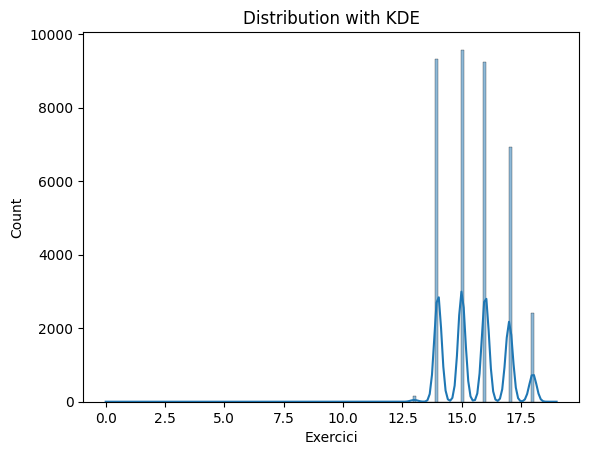

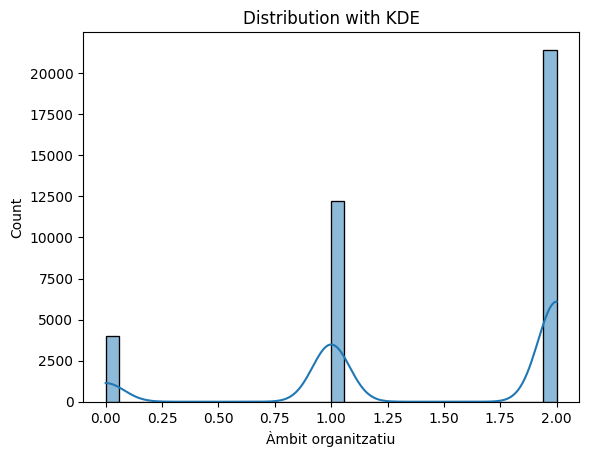

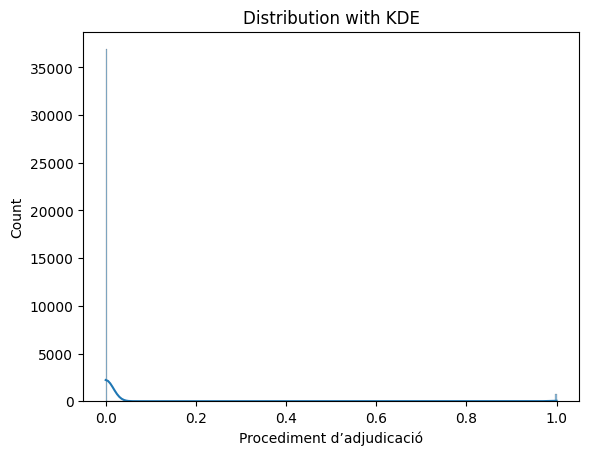

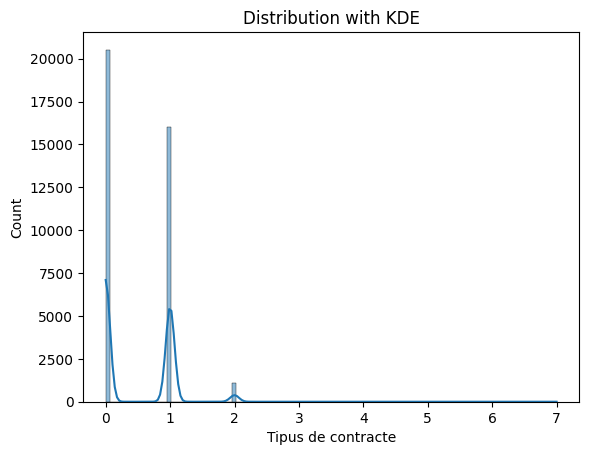

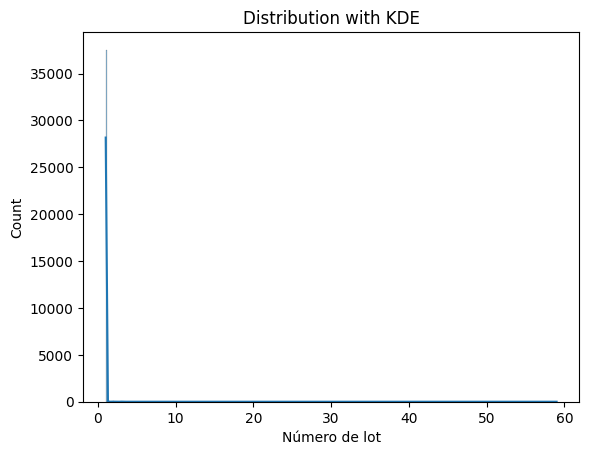

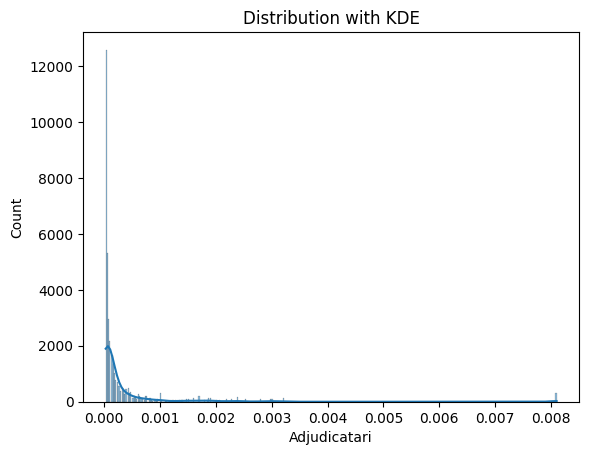

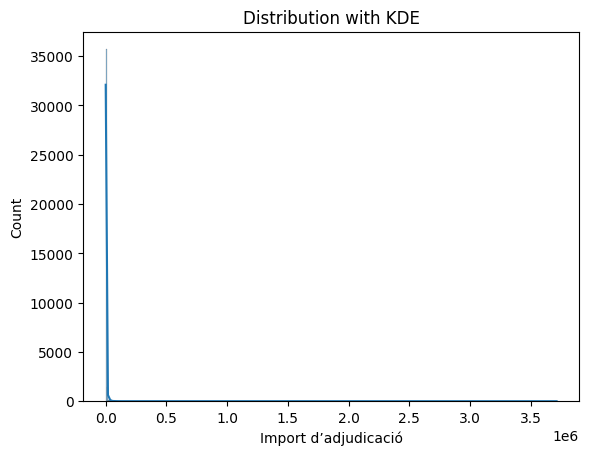

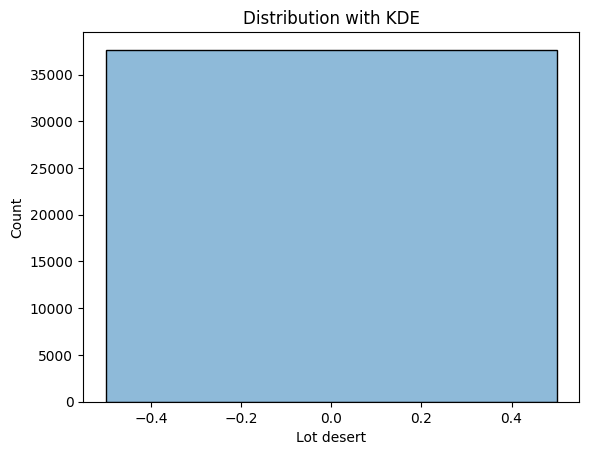

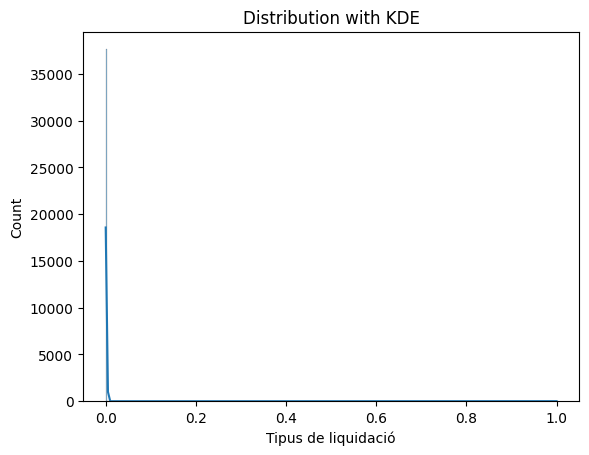

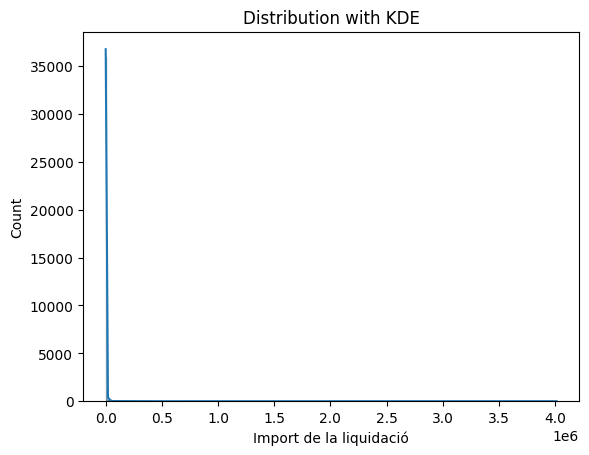

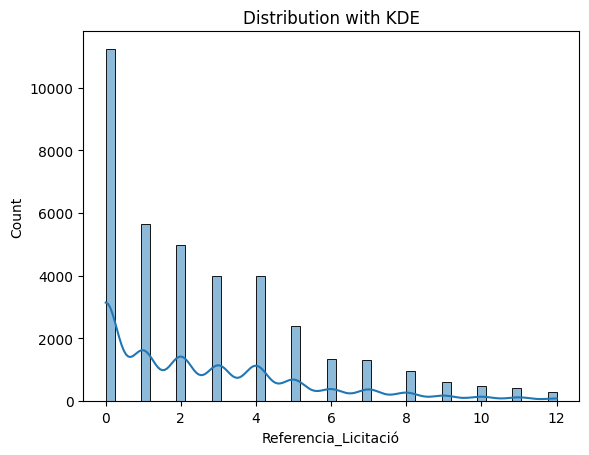

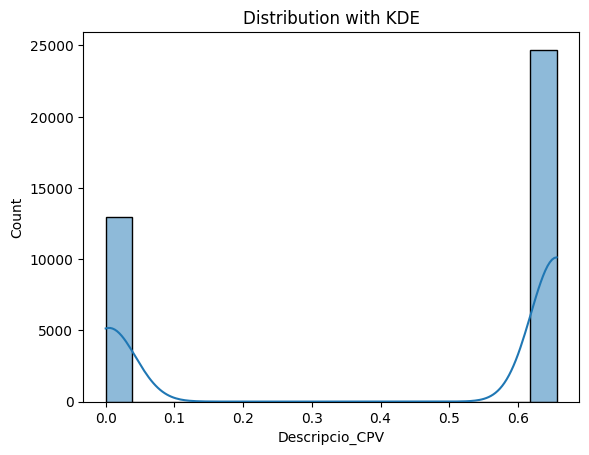

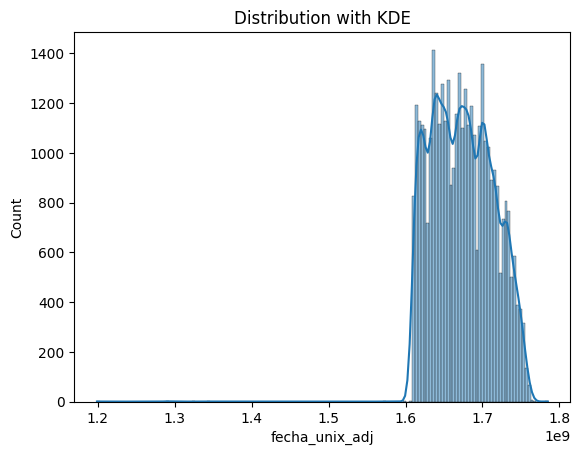

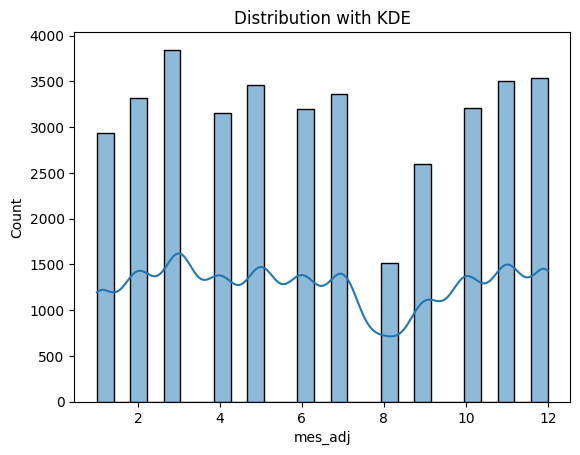

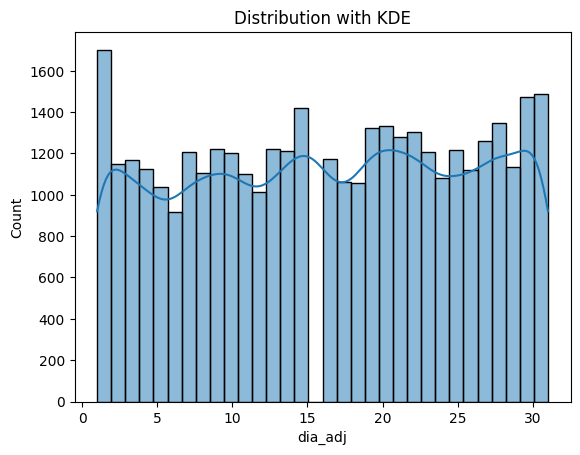

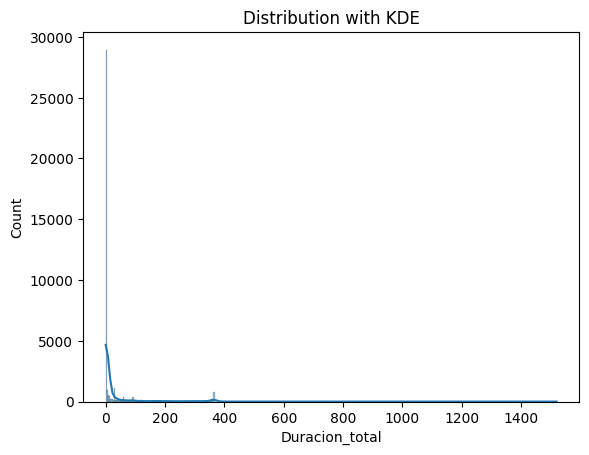

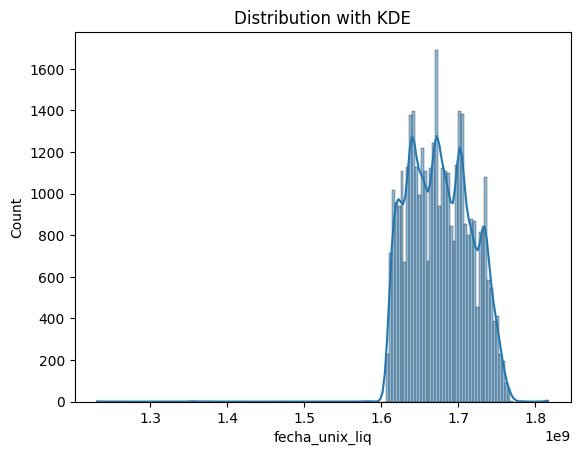

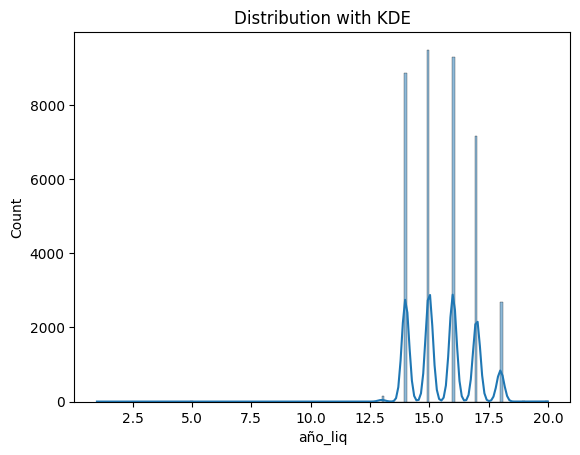

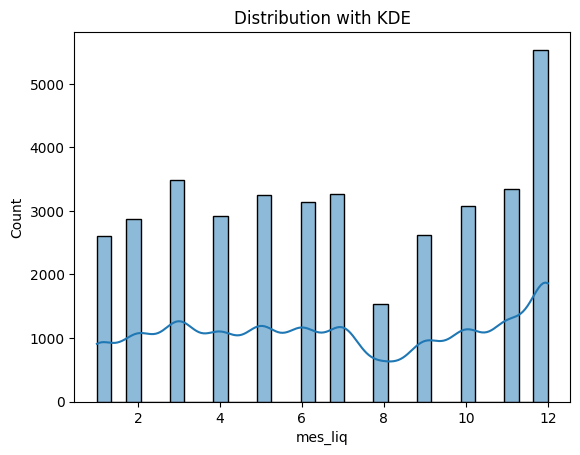

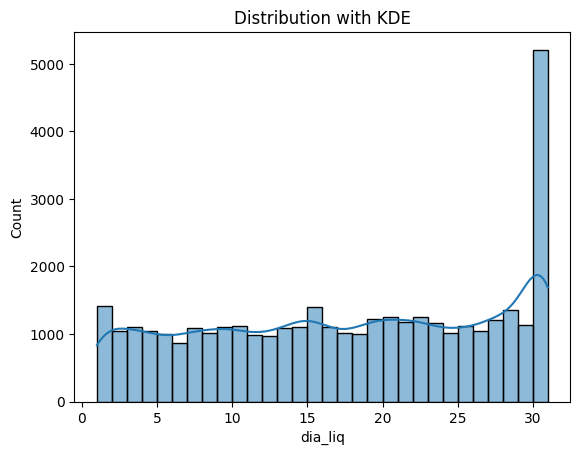

In [60]:

for feature in features_numericas:
    sns.histplot(df[feature], kde=True)
    plt.title('Distribution with KDE')
    plt.show()

In [61]:
'''
A partir de un analisis visual de la distribucion de cada una de las
features, podemos tratar de deducir cual de ellas necesitan una 
transformacion logaritmica, las pondremos en una lista temporalmente,
para aplicar la transformacion logaritmica en todas ellas de un
solo código. Haremos solo la transformacion de los importes de liquidacion y adjudicacion (target),
dado que el res
'''
logaritmicas = ["Procediment d’adjudicació","Número de lot", "Adjudicatari",
                "Import d’adjudicació","Tipus de liquidació",target, "Duracion_total",
                "fecha_unix_liq"
                ]

df[logaritmicas] = np.log1p(df[logaritmicas])


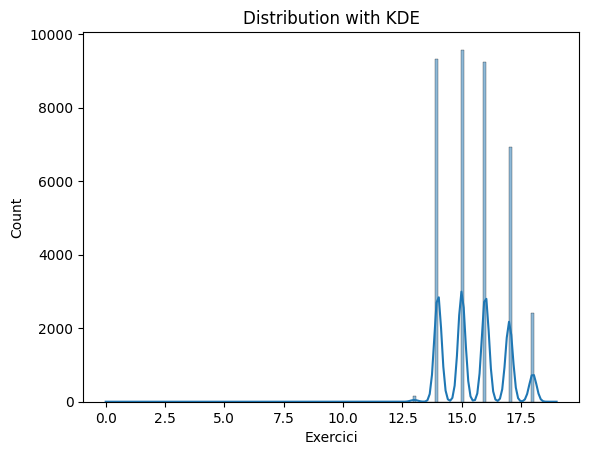

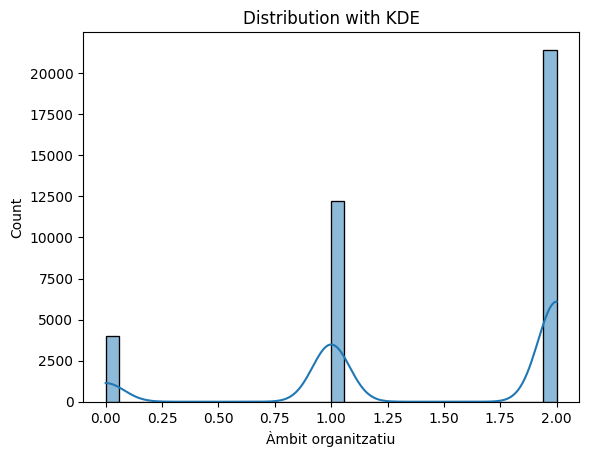

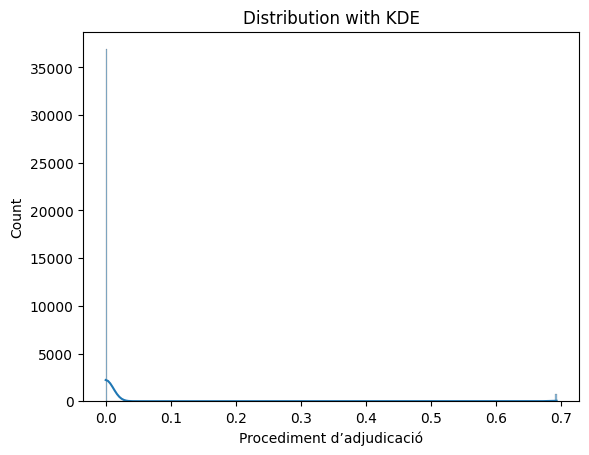

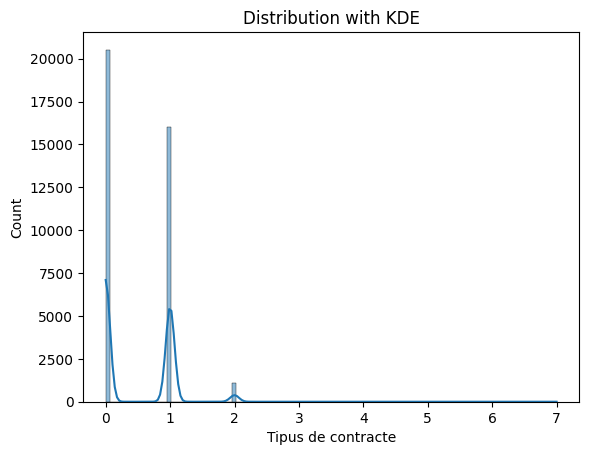

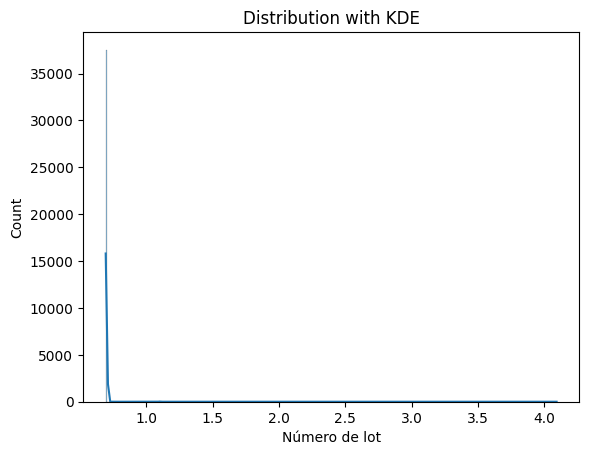

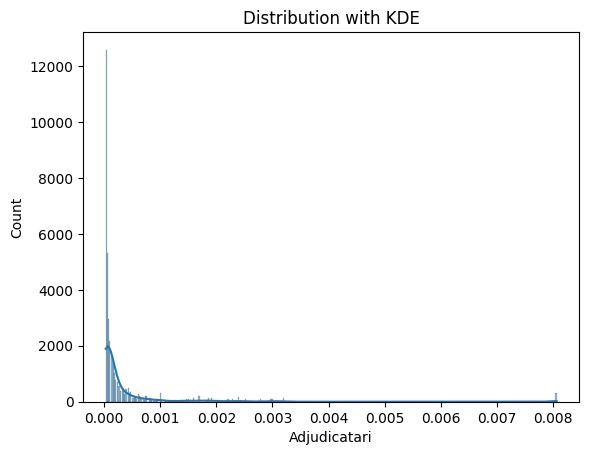

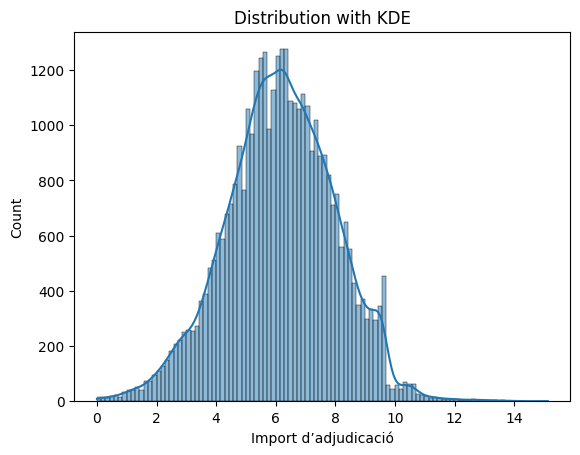

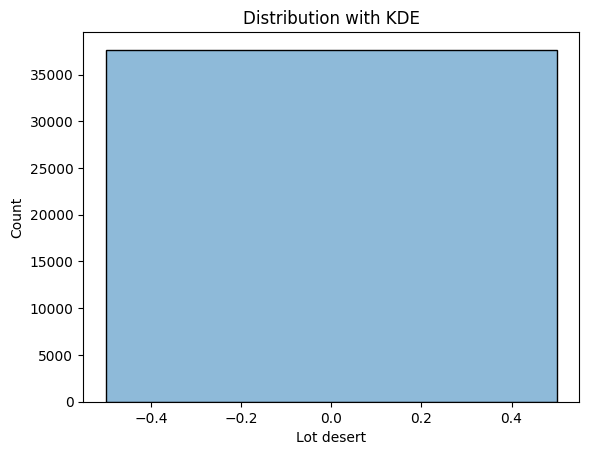

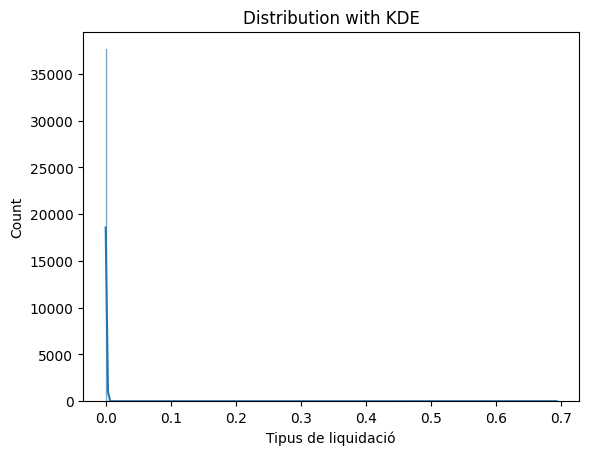

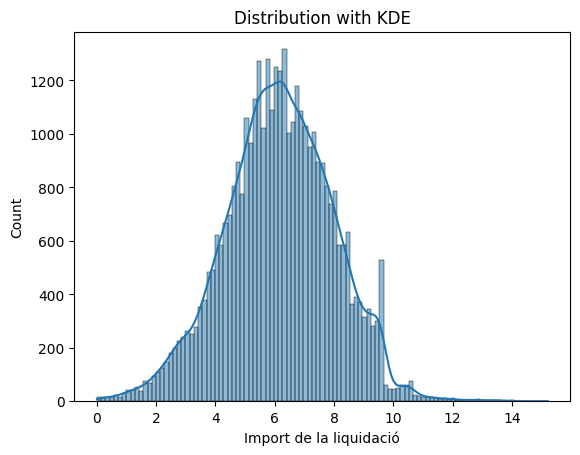

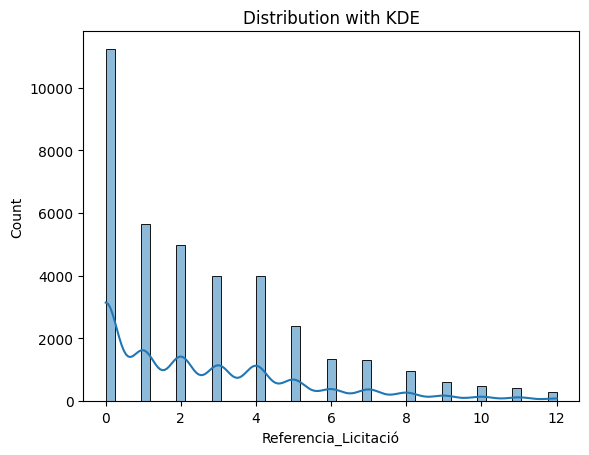

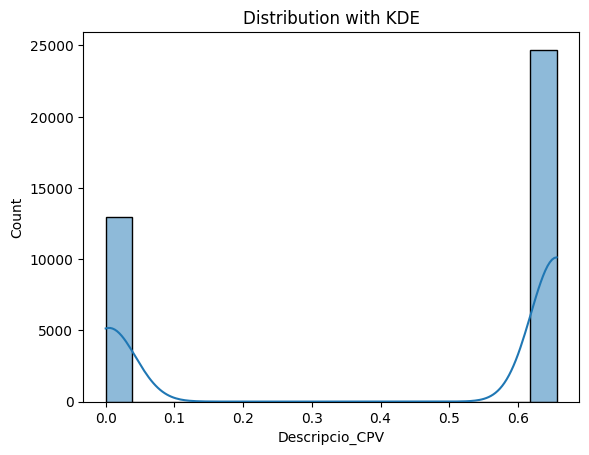

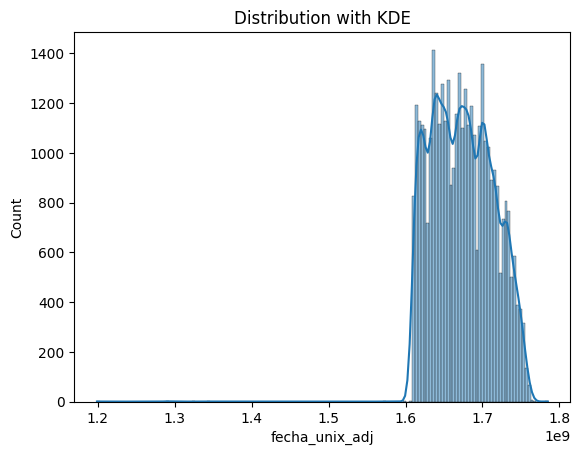

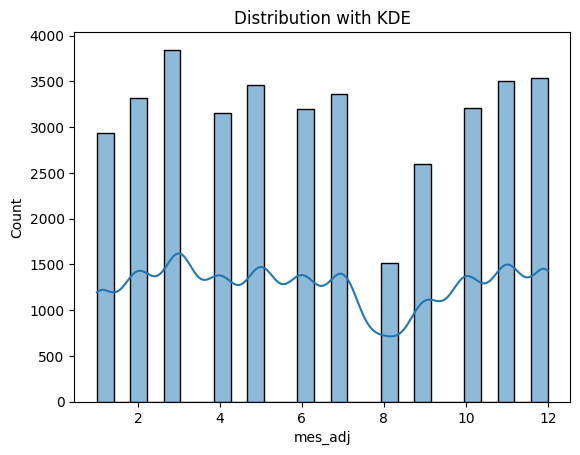

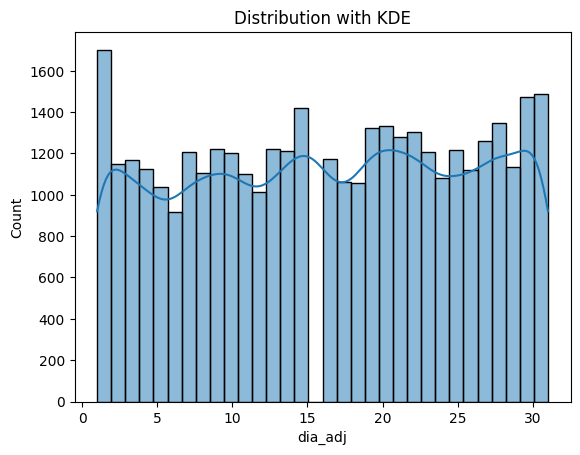

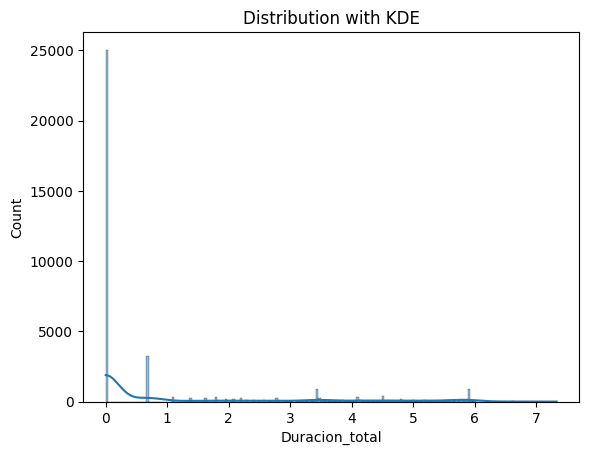

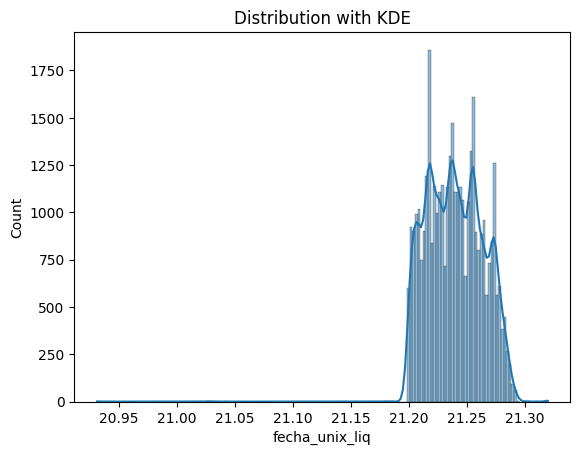

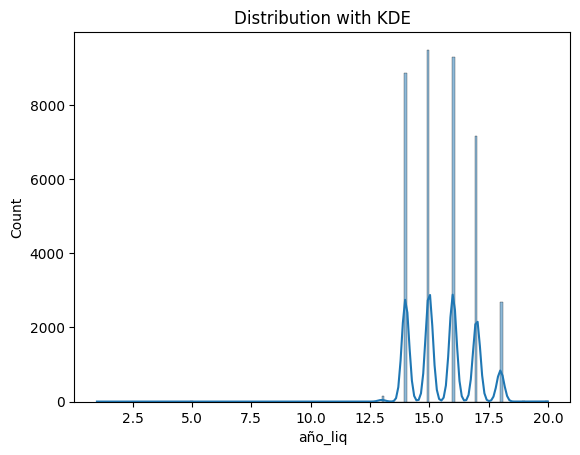

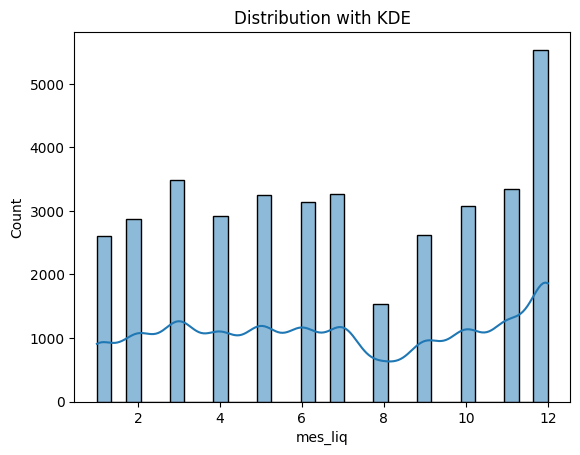

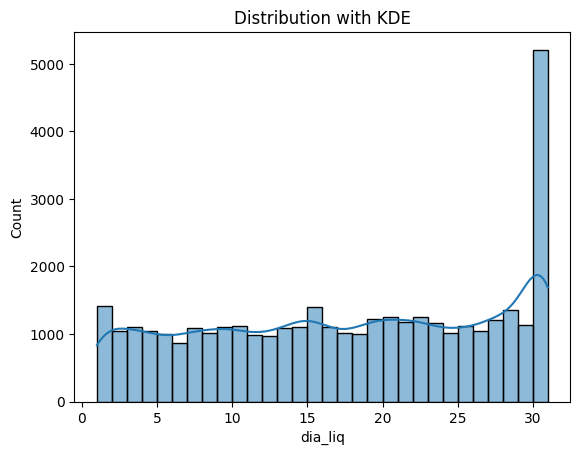

In [62]:

for feature in features_numericas:
    sns.histplot(df[feature], kde=True)
    plt.title('Distribution with KDE')
    plt.show()

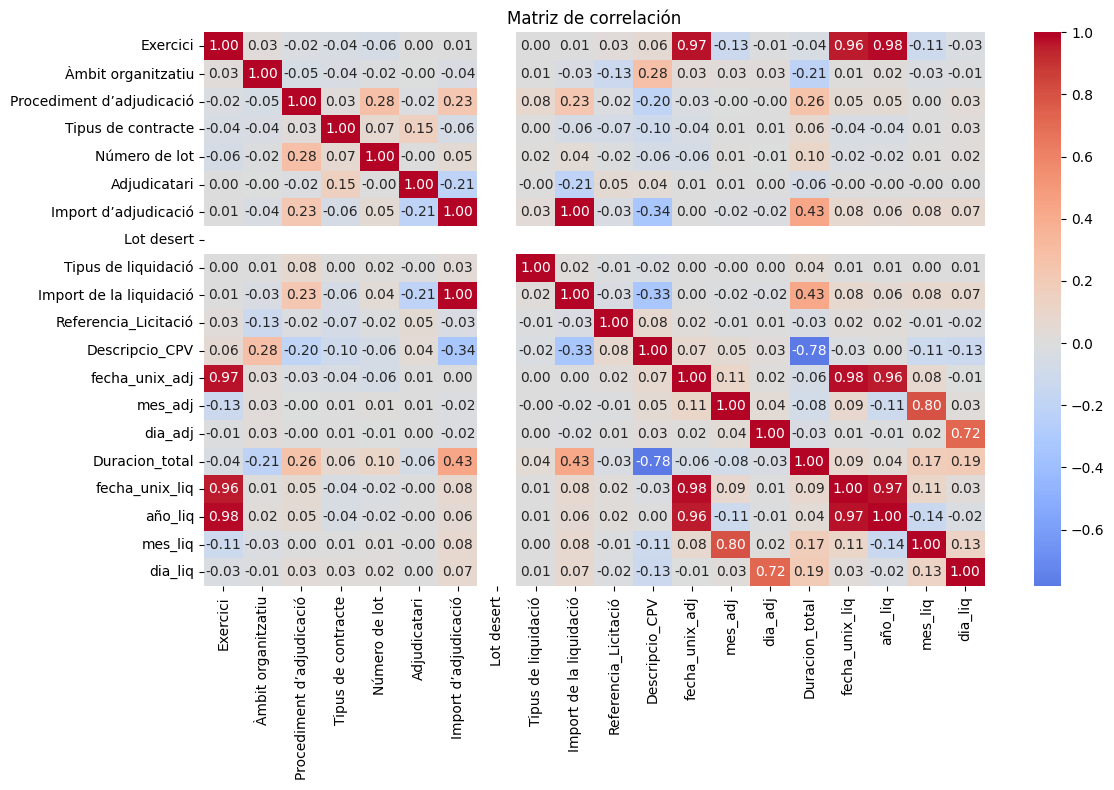

In [63]:
'''
Aqui tenemos mucha miga, asi que vamos a comentar por apartados. 
-1. Se confirman nuestras sosopechas de que el importe de la adjudicacion tiene un importe identico,
podemos suponer varias cosas al respecto de porque ocurre esto (Por ejemplo, la muestra que
hemos utilizado, desafortunadamente, se trata todo de obras sin cambios en el importe de 
adjudicacion, pese a ser altamente improbable. Personalmente opto porque los datos que son publicos
han pecado de vaguez en su debida diligencia, y han puesto el mismo importe sin ahondar en materia, pero
no podemos dejar que afecte el sesgo en un eda). 

-2. Las fechas que hay entre adjudicacion y liquidacion tienen una alta colinialidad, esto puede deberse
nuevamente por muchas razones. Puede ser porque, en un caso ideal, la mayoria de licitaciones han
cumplido con los plazos que fueron establecidos inicialmente en el proceso de adjudicación, y por
ello nos encontramos muchas coincidencias. Por supuesto, no podemos permitir que nuesto sesgo actue,
pese a la surrealidad de la situación. En casos normales, pensariamos que son categorias duplicadas,
pero como en realidad tienen significancia individual las conservamos.

-3. Vemos que las fechas unix no han sido buena idea, evidentemente tiene una alta colinialidad con
el resto de features que hacen referencia a fechas, asi que por el bien del proyecto, las eliminaremos.
Lo mismo ocurre con la fecha del año de liquidacion. Si vien pueden existir diferencias de fechas entre 
adjudicacion y liquidacion, es raro que salten de año, por lo que hay una alta colianidad con el año
de la adjudicacion, tambien lo aislamos del modelo.
'''

corr_matrix = df[features_numericas].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

In [64]:
features_numericas = ['Exercici', 'Àmbit organitzatiu', 'Procediment d’adjudicació',
       'Tipus de contracte', 'Número de lot',
       'Adjudicatari', 'Import d’adjudicació', 'Lot desert',
       'Tipus de liquidació', 'Import de la liquidació',
       'Referencia_Licitació',
       'Descripcio_CPV', 'mes_adj', 'dia_adj',
       'Duracion_total', 'mes_liq', 'dia_liq']

In [65]:
df = df[features_numericas + features_categoricas]

In [66]:
df

,Exercici,Àmbit organitzatiu,Procediment d’adjudicació,Tipus de contracte,Número de lot,Adjudicatari,Import d’adjudicació,Lot desert,Tipus de liquidació,Import de la liquidació,Referencia_Licitació,Descripcio_CPV,mes_adj,dia_adj,Duracion_total,mes_liq,dia_liq,Descripció de l’expedient,Causa de resolució
0,15,2,0.0,1,0.693147,0.000956,1.217876,0,0.0,1.217876,3,0.656229,2,8,0.000000,2,8,MOSQUETONS,
1,16,1,0.0,0,0.693147,0.000080,5.145632,0,0.0,5.145632,2,0.014023,11,14,0.693147,11,14,CRISTAL DCHO MTO,
2,17,2,0.0,1,0.693147,0.000133,3.846097,0,0.0,3.846097,0,0.656229,5,13,0.000000,5,13,AOC:172033646 Formatge manxego ventero / Pit d...,
3,14,1,0.0,0,0.693147,0.000027,7.673749,0,0.0,7.673749,6,0.000266,4,15,4.499810,6,15,"Producció gràfica, muntatge i desmuntatge exp ...",
4,18,2,0.0,0,0.693147,0.000027,6.781058,0,0.0,6.781058,0,0.656229,3,25,0.000000,3,25,Contractació de l'edició EXT2025/0445 de l'acc...,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37648,16,1,0.0,0,0.693147,0.000239,6.832741,0,0.0,6.832741,2,0.656229,2,24,0.000000,2,24,Formació i Docència,
37649,16,2,0.0,0,0.693147,0.000106,7.824446,0,0.0,7.824446,5,0.656229,12,13,0.000000,12,13,CULTURA - Contractar diferents espectacles esc...,
37650,14,1,0.0,0,0.693147,0.000106,5.398163,0,0.0,5.398163,1,0.656229,12,15,0.000000,12,15,OHB_IIAB: Quata mensual manteniment informàtic...,
37651,18,1,0.0,0,0.693147,0.000027,8.751865,0,0.0,8.751865,1,0.000027,7,4,3.433987,8,3,Servei treball pintura taller manteniment Ribes,


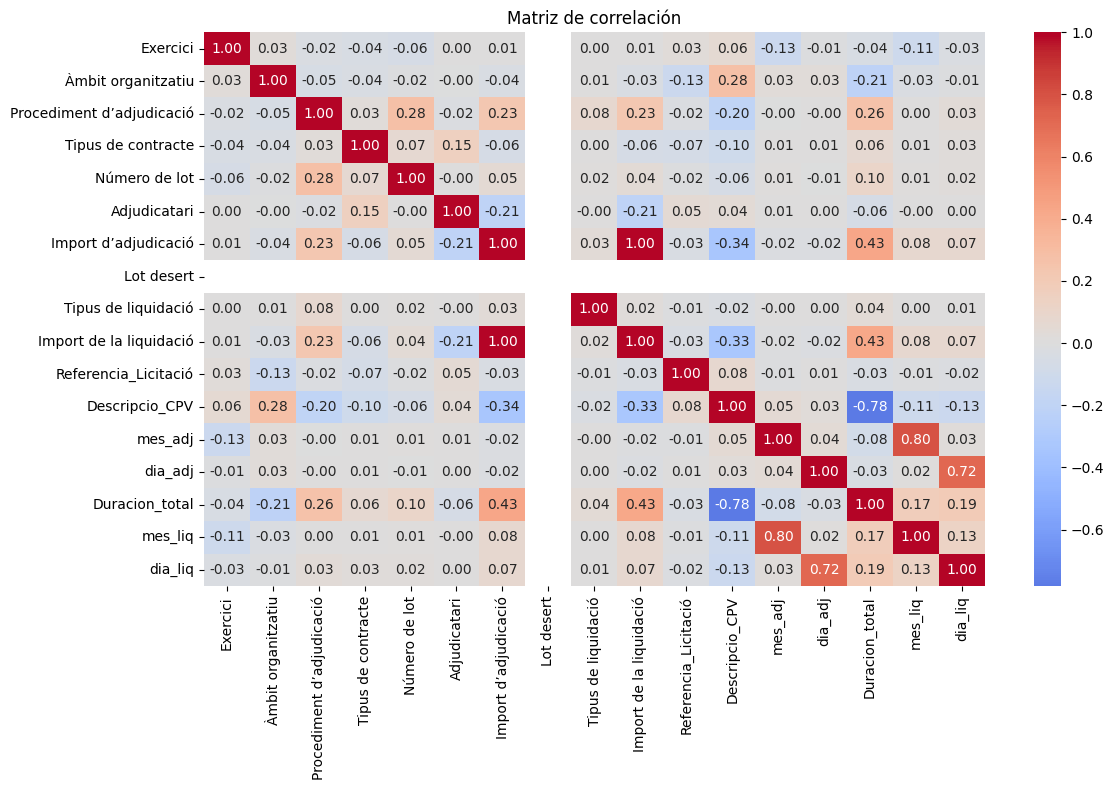

In [67]:
corr_matrix = df[features_numericas].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

In [50]:
features_numericas

['Exercici',
 'Àmbit organitzatiu',
 'Procediment d’adjudicació',
 'Tipus de contracte',
 'Número de lot',
 'Adjudicatari',
 'Import d’adjudicació',
 'Lot desert',
 'Tipus de liquidació',
 'Import de la liquidació',
 'Referencia_Licitació',
 'Descripcio_CPV',
 'mes_adj',
 'dia_adj',
 'Duracion_total',
 'mes_liq',
 'dia_liq']

In [51]:
'''
En el siguiente apartado, para decidir cuales son las variables mas acertadas como las 'principales'
haremos uso de la correlacion de spearman
'''
features_numericas.remove("Import de la liquidació")

for feature in features_numericas:
    correlacion_spearman = df[target].corr(df[feature], method='spearman')
    print(f"Correlación de Spearman {feature}: {correlacion_spearman}")

Correlación de Spearman Exercici: 0.020295096268699096
Correlación de Spearman Àmbit organitzatiu: -0.04574425984134389
Correlación de Spearman Procediment d’adjudicació: 0.1687442628856391
Correlación de Spearman Tipus de contracte: -0.12584783056802437
Correlación de Spearman Número de lot: 0.06054917812920436
Correlación de Spearman Adjudicatari: -0.2606141120508012
Correlación de Spearman Import d’adjudicació: 0.998260997198178
Correlación de Spearman Lot desert: nan
Correlación de Spearman Tipus de liquidació: 0.019631327795436262
Correlación de Spearman Referencia_Licitació: -0.029696601327477177
Correlación de Spearman Descripcio_CPV: -0.35270296162220754
Correlación de Spearman mes_adj: -0.018362117007615687
Correlación de Spearman dia_adj: -0.025007078963751966
Correlación de Spearman Duracion_total: 0.35764918289905473
Correlación de Spearman mes_liq: 0.07722587474306408
Correlación de Spearman dia_liq: 0.07278955884462408


c:\Users\Dani\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


In [52]:
features_numericas = ['Exercici', 'Àmbit organitzatiu', 'Procediment d’adjudicació',
       'Tipus de contracte', 'Número de lot',
       'Adjudicatari', 'Lot desert',
       'Tipus de liquidació',
       'Referencia_Licitació',
       'Descripcio_CPV', 'mes_adj', 'dia_adj',
       'Duracion_total', 'mes_liq', 'dia_liq']

In [53]:
'''
Para la facilidad del modelo nos desharemos de las features categoricas o de texto
libre, dado que no sabemos como hacer la transformación, y sacarle partido al
rendimiento de la feature al modelo
'''
df = df[features_numericas + [target]]

In [54]:
'''
Ahora que hemos llegado a este punto, observamos que las features guardan una relacion muy debil con
la target, dejando de lado el importe de adjudicacion, que habiamos visto anteriormente.
Seguiremos entrenando el modelo teniendo presente esto. 
'''
train_set, test_set = train_test_split(df, test_size= 0.2, random_state= 42)


In [55]:
X_train = train_set.drop(target, axis = 1)
y_train = train_set[target]

X_test = test_set.drop(target, axis = 1)
y_test = test_set[target]

In [56]:
rf_reg = RandomForestRegressor(max_depth = 10, random_state= 42)
lgb_reg = LGBMRegressor(max_depth = 10, random_state = 42, verbose = -1)
xgb_reg = XGBRegressor(max_depth = 10, random_state = 42)

modelos_reg = {
    "Random Forest": rf_reg,
    "LightGBM": lgb_reg,
    "XGBoost Regressor": xgb_reg
}

In [57]:
for nombre, modelo in zip(["XGBRegressor","LGBMRegressor","RandomForestRegressor"],[xgb_reg, lgb_reg, rf_reg]):
    print(f"Para {nombre}:", end = " ")
    print("neg_mean_absolute error:", np.mean(cross_val_score(modelo, X_train, y_train, cv = 5, scoring = "neg_root_mean_squared_error")))

Para XGBRegressor: neg_mean_absolute error: -1.5396683773105435
Para LGBMRegressor: neg_mean_absolute error: -1.4291306061303088
Para RandomForestRegressor: neg_mean_absolute error: -1.4435754166773274


In [58]:
'''
Vemos que los que dan mejor resultado se tratan del lgbm y del randomforestregressor,
haremos un estudio con optuna con ambos modelos para ver que resultados nos muestran
'''

'\nVemos que los que dan mejor resultado se tratan del lgbm y del randomforestregressor,\nharemos un estudio con optuna con ambos modelos para ver que resultados nos muestran\n'

In [59]:
def objective(trial):
    param_grid = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 70),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "absolute_error"]),
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0)
    }

    model = LGBMRegressor(**param_grid, random_state=42, n_jobs=-1)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    ).mean()

    return score

In [60]:
study = optuna.create_study(direction="maximize", 
                            sampler=optuna.samplers.TPESampler(seed=42))

[I 2026-03-02 20:42:22,403] A new study created in memory with name: no-name-84fcd30f-8d93-4e8b-8835-cb7593299947


In [61]:
study.optimize(objective, n_trials=20)

[I 2026-03-02 20:42:26,703] Trial 0 finished with value: -1.4255656473239322 and parameters: {'n_estimators': 362, 'max_depth': 67, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'squared_error', 'max_samples': 0.8540362888980227}. Best is trial 0 with value: -1.4255656473239322.
[I 2026-03-02 20:42:29,539] Trial 1 finished with value: -1.4295255022246445 and parameters: {'n_estimators': 114, 'max_depth': 68, 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features': None, 'criterion': 'squared_error', 'max_samples': 0.645614570099021}. Best is trial 0 with value: -1.4255656473239322.
[I 2026-03-02 20:42:33,979] Trial 2 finished with value: -1.4290817918960372 and parameters: {'n_estimators': 528, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'absolute_error', 'max_samples': 0.5232252063599989}. Best is trial 0 with value: -1.4255656473239322.
[I 2026-03-02 20:42:37,501] Trial 3 finished w

In [62]:
optuna.visualization.plot_param_importances(study)

In [63]:
optuna.visualization.plot_optimization_history(study)

In [64]:
best_params = study.best_params

In [65]:
best_n_estimators = best_params["n_estimators"]
best_max_depth = best_params["max_depth"]
best_min_samples_split = best_params["min_samples_split"]
best_min_samples_leaf = best_params["min_samples_leaf"]
best_max_features = best_params["max_features"]
best_criterion = best_params["criterion"]
best_max_samples = best_params["max_samples"]

In [66]:
best_lgbm_model = LGBMRegressor(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    max_features=best_max_features,
    criterion=best_criterion,
    max_samples=best_max_samples,
    random_state=42,
    n_jobs=-1
)

In [67]:
def objective(trial):
    param_grid = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 70),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "absolute_error"]),
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0)
    }

    model = RandomForestRegressor(**param_grid, random_state=42, n_jobs=-1)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    ).mean()

    return score

In [68]:
study = optuna.create_study(direction="maximize", 
                            sampler=optuna.samplers.TPESampler(seed=42))

[I 2026-03-02 20:43:04,154] A new study created in memory with name: no-name-c9447eeb-4d82-4fb8-8f6b-e8c4875f86b5


In [69]:
'''
Me peta el ordenador si pongo muchos trials, lo limito a 10 por el bien de la
integridad de mis componentes hahaha
'''

study.optimize(objective, n_trials=10)

[I 2026-03-02 20:43:06,942] Trial 0 finished with value: -1.4501646406889446 and parameters: {'n_estimators': 362, 'max_depth': 67, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'squared_error', 'max_samples': 0.8540362888980227}. Best is trial 0 with value: -1.4501646406889446.
[I 2026-03-02 20:43:09,325] Trial 1 finished with value: -1.4431597293853955 and parameters: {'n_estimators': 114, 'max_depth': 68, 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features': None, 'criterion': 'squared_error', 'max_samples': 0.645614570099021}. Best is trial 1 with value: -1.4431597293853955.
[I 2026-03-02 20:43:30,457] Trial 2 finished with value: -1.459667596040752 and parameters: {'n_estimators': 528, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'absolute_error', 'max_samples': 0.5232252063599989}. Best is trial 1 with value: -1.4431597293853955.
[I 2026-03-02 20:43:57,156] Trial 3 finished wi

In [70]:
optuna.visualization.plot_param_importances(study)

In [71]:
optuna.visualization.plot_optimization_history(study)

In [72]:
best_params = study.best_params

In [73]:
best_n_estimators = best_params["n_estimators"]
best_max_depth = best_params["max_depth"]
best_min_samples_split = best_params["min_samples_split"]
best_min_samples_leaf = best_params["min_samples_leaf"]
best_max_features = best_params["max_features"]
best_criterion = best_params["criterion"]
best_max_samples = best_params["max_samples"]

In [74]:
best_rf_model = RandomForestRegressor(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    max_features=best_max_features,
    criterion=best_criterion,
    max_samples=best_max_samples,
    random_state=42,
    n_jobs=-1
)

In [75]:
best_lgbm_model.fit(X_train,y_train)


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,45
,learning_rate,0.1
,n_estimators,294
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [76]:
best_rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",114
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",68
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",17
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [77]:
y_pred_lgbm = best_lgbm_model.predict(X_test)
y_pred_rf = best_rf_model.predict(X_test)

In [78]:
print(round(root_mean_squared_error(y_test, y_pred_lgbm),4))
print(round(root_mean_squared_error(y_test, y_pred_rf),4))


1.4196
1.4309


In [79]:
#joblib.dump(y_pred_lgbm, '../models/lgbm.pkl')


In [80]:
#joblib.dump(y_pred_rf, '../models/rf.pkl')


In [81]:
df

,Exercici,Àmbit organitzatiu,Procediment d’adjudicació,Tipus de contracte,Número de lot,Adjudicatari,Lot desert,Tipus de liquidació,Referencia_Licitació,Descripcio_CPV,mes_adj,dia_adj,Duracion_total,mes_liq,dia_liq,Import de la liquidació
0,15,2,0.0,1,0.693147,0.000956,0,0.0,3,0.656229,2,8,0.000000,2,8,1.217876
1,16,1,0.0,0,0.693147,0.000080,0,0.0,2,0.014023,11,14,0.693147,11,14,5.145632
2,17,2,0.0,1,0.693147,0.000133,0,0.0,0,0.656229,5,13,0.000000,5,13,3.846097
3,14,1,0.0,0,0.693147,0.000027,0,0.0,6,0.000266,4,15,4.499810,6,15,7.673749
4,18,2,0.0,0,0.693147,0.000027,0,0.0,0,0.656229,3,25,0.000000,3,25,6.781058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37648,16,1,0.0,0,0.693147,0.000239,0,0.0,2,0.656229,2,24,0.000000,2,24,6.832741
37649,16,2,0.0,0,0.693147,0.000106,0,0.0,5,0.656229,12,13,0.000000,12,13,7.824446
37650,14,1,0.0,0,0.693147,0.000106,0,0.0,1,0.656229,12,15,0.000000,12,15,5.398163
37651,18,1,0.0,0,0.693147,0.000027,0,0.0,1,0.000027,7,4,3.433987,8,3,8.751865


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37651 entries, 0 to 37652
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Exercici                   37651 non-null  int64  
 1   Àmbit organitzatiu         37651 non-null  int64  
 2   Procediment d’adjudicació  37651 non-null  float64
 3   Tipus de contracte         37651 non-null  int64  
 4   Número de lot              37651 non-null  float64
 5   Adjudicatari               37651 non-null  float64
 6   Lot desert                 37651 non-null  int64  
 7   Tipus de liquidació        37651 non-null  float64
 8   Referencia_Licitació       37651 non-null  int64  
 9   Descripcio_CPV             37651 non-null  float64
 10  mes_adj                    37651 non-null  int32  
 11  dia_adj                    37651 non-null  int32  
 12  Duracion_total             37651 non-null  float64
 13  mes_liq                    37651 non-null  int32  
